In [ ]:
import pandas as pd
import numpy as np

In [ ]:
np.random.seed(42)

data = {
    'Product_ID': range(1, 101),
    'Original_Price': np.random.randint(500, 5000, 100),
    'Demand': np.random.randint(1, 100, 100),
    'Stock': np.random.randint(10, 500, 100),
    'Competitor_Price': np.random.randint(400, 4800, 100),
    'Discount': np.random.randint(5, 40, 100)
}

df = pd.DataFrame(data)

df.head()

,Product_ID,Original_Price,Demand,Stock,Competitor_Price,Discount
0,1,1360,79,106,1618,13
1,2,4272,15,210,3504,16
2,3,3592,90,133,3135,5
3,4,966,42,196,1354,5
4,5,4926,77,335,3846,38


In [ ]:
df.head()

,Product_ID,Original_Price,Demand,Stock,Competitor_Price,Discount
0,1,1360,79,106,1618,13
1,2,4272,15,210,3504,16
2,3,3592,90,133,3135,5
3,4,966,42,196,1354,5
4,5,4926,77,335,3846,38


In [ ]:
df['Final_Price'] = (
    df['Original_Price']
    + df['Demand'] * 5
    - df['Stock'] * 2
    + df['Competitor_Price'] * 0.3
    - df['Discount'] * 10
    + np.random.randint(-500, 500, 100)
)

df.head()

,Product_ID,Original_Price,Demand,Stock,Competitor_Price,Discount,Final_Price
0,1,1360,79,106,1618,13,1794.4
1,2,4272,15,210,3504,16,5016.2
2,3,3592,90,133,3135,5,4184.5
3,4,966,42,196,1354,5,816.2
4,5,4926,77,335,3846,38,5525.8


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product_ID        100 non-null    int64  
 1   Original_Price    100 non-null    int64  
 2   Demand            100 non-null    int64  
 3   Stock             100 non-null    int64  
 4   Competitor_Price  100 non-null    int64  
 5   Discount          100 non-null    int64  
 6   Final_Price       100 non-null    float64
dtypes: float64(1), int64(6)
memory usage: 5.6 KB


In [ ]:
df.isnull().sum()

,0
Product_ID,0
Original_Price,0
Demand,0
Stock,0
Competitor_Price,0
Discount,0
Final_Price,0


In [ ]:
X = df[['Original_Price',
        'Demand',
        'Stock',
        'Competitor_Price',
        'Discount']]

y = df['Final_Price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[3056.14349175 4624.88104631 4450.89621541 4213.73275126 2150.88015734]


In [ ]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print("Accuracy Score:", score)

Accuracy Score: 0.9436964072284905


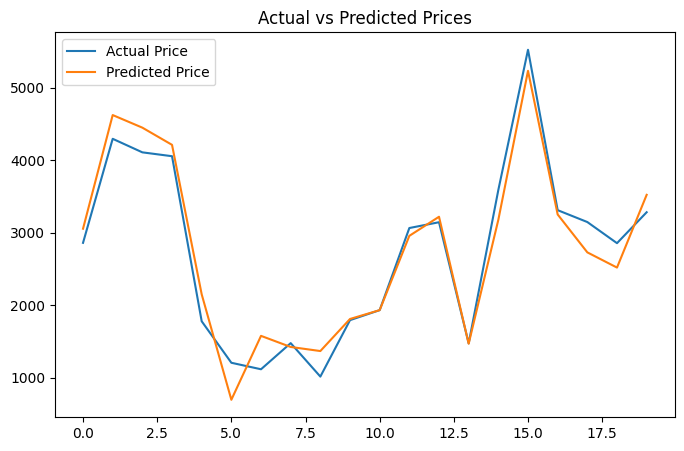

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')

plt.legend()

plt.title("Actual vs Predicted Prices")

plt.show()

In [ ]:
sample = [[3000, 80, 50, 3200, 10]]

predicted_price = model.predict(sample)

print("Predicted Dynamic Price:", predicted_price)

Predicted Dynamic Price: [3977.4588744]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
